# Data Download

In [1]:
import fastf1
import os

# 1. 캐시 폴더 설정 (데이터를 저장해두고 빠르게 불러오기 위함)
# 현재 경로에 'cache' 폴더가 없으면 생성
cache_dir = 'fastf1_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

fastf1.Cache.enable_cache(cache_dir) 

print("🔵 데이터 로드 시작... (첫 실행 시 시간이 걸릴 수 있습니다)")

# ==========================================
# A. Qualifying 세션 로드 (기준점 - Baseline)
# ==========================================
print("\n--- Loading Qualifying Session (Baseline) ---")
session_quali = fastf1.get_session(2023, 'Suzuka', 'Q')
session_quali.load() # 랩타임, 텔레메트리, 날씨 등 모든 데이터 로드

# 퀄리파잉 Flying Lap 필터링 (앞서 논의한 로직 적용)
quali_laps = session_quali.laps.pick_wo_box().pick_accurate()
pole_time = session_quali.laps.pick_fastest()['LapTime']
# 107% 룰 적용하여 Cool-down lap 제거
threshold = pole_time * 1.07
best_flying_laps = quali_laps[quali_laps['LapTime'] <= threshold]

print(f"✅ Quali 로드 완료: 총 {len(best_flying_laps)}개의 Flying Laps 확보")


# ==========================================
# B. Race 세션 로드 (분석 대상 - Main)
# ==========================================
print("\n--- Loading Race Session (Main Analysis) ---")
session_race = fastf1.get_session(2023, 'Suzuka', 'R')
session_race.load()

# 레이스 데이터는 별도 필터링 없이 전체를 가져오되, 정확도 필터만 적용
race_laps = session_race.laps.pick_accurate()

print(f"✅ Race 로드 완료: 총 {len(race_laps)}개의 Clean Laps 확보")

# ==========================================
# C. 데이터 확인
# ==========================================
print("\n[데이터 샘플 확인]")
print(f"Event: {session_race.event['EventName']}")
print(f"Track: {session_race.event['Location']}")
print("-" * 30)
print("Race Laps Columns:", race_laps.columns.tolist())

🔵 데이터 로드 시작... (첫 실행 시 시간이 걸릴 수 있습니다)

--- Loading Qualifying Session (Baseline) ---


core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO

✅ Quali 로드 완료: 총 75개의 Flying Laps 확보

--- Loading Race Session (Main Analysis) ---


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

✅ Race 로드 완료: 총 702개의 Clean Laps 확보

[데이터 샘플 확인]
Event: Japanese Grand Prix
Track: Suzuka
------------------------------
Race Laps Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


# EDA

In [4]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 캐시 폴더 설정 (없으면 자동 생성)
fastf1.Cache.enable_cache('fastf1_cache')

# 차트 스타일 설정
fastf1.plotting.setup_mpl()
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams['figure.figsize'] = [12, 6]

In [7]:
# --- 1. Session Load ---
print("Loading Sessions...")
# Qualifying
quali = fastf1.get_session(2023, 'Suzuka', 'Q')
quali.load()

# Race
race = fastf1.get_session(2023, 'Suzuka', 'R')
race.load(telemetry=True, weather=False, messages=False)

print("Data Loaded Successfully.")

# --- 2. Dataset A: Quali - Flying Laps ---
# 수정됨: 'IsFlyingLap' 컬럼이 없어도 에러가 나지 않도록 변경
# pick_wo_box(): 피트 인/아웃 랩 제거
# pick_accurate(): 옐로우 플래그 등 비정상 랩 제거
ds_a = quali.laps.pick_wo_box().pick_accurate().copy()

# (선택 사항) 만약 컬럼이 존재할 때만 더 엄격하게 필터링
if 'IsFlyingLap' in ds_a.columns:
    ds_a = ds_a[ds_a['IsFlyingLap'] == True]

ds_a['Scenario'] = 'A_Quali_Flying'

# --- 3. Race Preprocessing for Dataset B & C ---
race_laps = race.laps.pick_wo_box().pick_accurate().copy()

# Gap to car ahead 계산 로직
race_laps = race_laps.sort_values(by=['LapNumber', 'Position'])
race_laps['GapToAhead'] = race_laps.groupby('LapNumber')['Time'].diff().dt.total_seconds()

# Dataset B: Clean Air (Gap > 1.5s OR P1)
ds_b = race_laps[(race_laps['GapToAhead'] > 1.5) | (race_laps['GapToAhead'].isna())].copy()
ds_b['Scenario'] = 'B_Clean_Air'

# Dataset C: Dirty Air / Battle (Gap <= 1.5s)
ds_c = race_laps[race_laps['GapToAhead'] <= 1.5].copy()
ds_c['Scenario'] = 'C_Dirty_Air'

print(f"Dataset A (Quali) samples: {len(ds_a)}")
print(f"Dataset B (Clean Air) samples: {len(ds_b)}")# --- 1. Session Load ---
print("Loading Sessions...")
# Qualifying
quali = fastf1.get_session(2023, 'Suzuka', 'Q')
quali.load()

# Race
race = fastf1.get_session(2023, 'Suzuka', 'R')
race.load(telemetry=True, weather=False, messages=False)

print("Data Loaded Successfully.")

# --- 2. Dataset A: Quali - Flying Laps ---
ds_a = quali.laps.pick_wo_box().pick_accurate().copy()

# IsFlyingLap 컬럼이 있으면 활용, 없으면 생략 (안전한 로직)
if 'IsFlyingLap' in ds_a.columns:
    ds_a = ds_a[ds_a['IsFlyingLap'] == True]

ds_a['Scenario'] = 'A_Quali_Flying'

# --- 3. Race Preprocessing for Dataset B & C (Advanced Battle Logic) ---
race_laps = race.laps.pick_wo_box().pick_accurate().copy()

# 같은 LapNumber 내에서 Position 순으로 정렬
race_laps = race_laps.sort_values(by=['LapNumber', 'Position'])

# 1. GapToAhead: 내 시간 - 앞차 시간
# (같은 랩의 바로 앞 순위 차와의 차이)
race_laps['GapToAhead'] = race_laps.groupby('LapNumber')['Time'].diff().dt.total_seconds()

# 2. GapToBehind: 뒷차 시간 - 내 시간
# (Shift(-1)을 사용하여 바로 뒷 순위 차(다음 행)의 GapToAhead 값을 가져오거나, 역으로 계산)
# diff(-1)은 (현재 행 - 다음 행)이므로 부호를 뒤집어 줍니다.
race_laps['GapToBehind'] = race_laps.groupby('LapNumber')['Time'].diff(-1).dt.total_seconds().abs()

# --- Dataset Separation Logic ---

# Battle Condition (Dirty Air):
# 앞차와 1.5초 이내 (공격 중) OR 뒷차와 1.5초 이내 (방어 중)
battle_mask = (race_laps['GapToAhead'] <= 1.5) | (race_laps['GapToBehind'] <= 1.5)

# Dataset C: Battle / Dirty Air
ds_c = race_laps[battle_mask].copy()
ds_c['Scenario'] = 'C_Battle_Defense' # 명칭을 조금 더 구체화했습니다.

# Dataset B: Clean Air / Pure Pace
# 배틀 상황이 아닌 모든 랩 (앞뒤 모두 1.5초 이상 비어있거나 차가 없음)
# ~battle_mask를 사용하여 배틀이 아닌 것만 필터링
ds_b = race_laps[~battle_mask].copy()
ds_b['Scenario'] = 'B_Clean_Air'

print(f"Dataset A (Quali) samples: {len(ds_a)}")
print(f"Dataset B (Clean Air) samples: {len(ds_b)}")
print(f"Dataset C (Battle/Defense) samples: {len(ds_c)}")

# 검증용 출력 (상위 5개 행의 Gap 정보 확인)
print("\n[Sample Data Check]")
print(ds_c[['Driver', 'LapNumber', 'Position', 'GapToAhead', 'GapToBehind']].head())
print(f"Dataset C (Dirty Air) samples: {len(ds_c)}")

Loading Sessions...


core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached

Data Loaded Successfully.
Dataset A (Quali) samples: 75
Dataset B (Clean Air) samples: 553
Loading Sessions...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req     

Data Loaded Successfully.
Dataset A (Quali) samples: 75
Dataset B (Clean Air) samples: 472
Dataset C (Battle/Defense) samples: 230

[Sample Data Check]
    Driver  LapNumber  Position  GapToAhead  GapToBehind
110    PIA        5.0       3.0       1.564        0.664
163    LEC        5.0       4.0       0.664        0.588
269    SAI        5.0       5.0       0.588        0.732
375    ALO        5.0       6.0       0.732        1.267
322    RUS        5.0       7.0       1.267        0.223
Dataset C (Dirty Air) samples: 230


## Race Clean Air(Gap > 1.5s) Lap time Distribution (z>2.0)

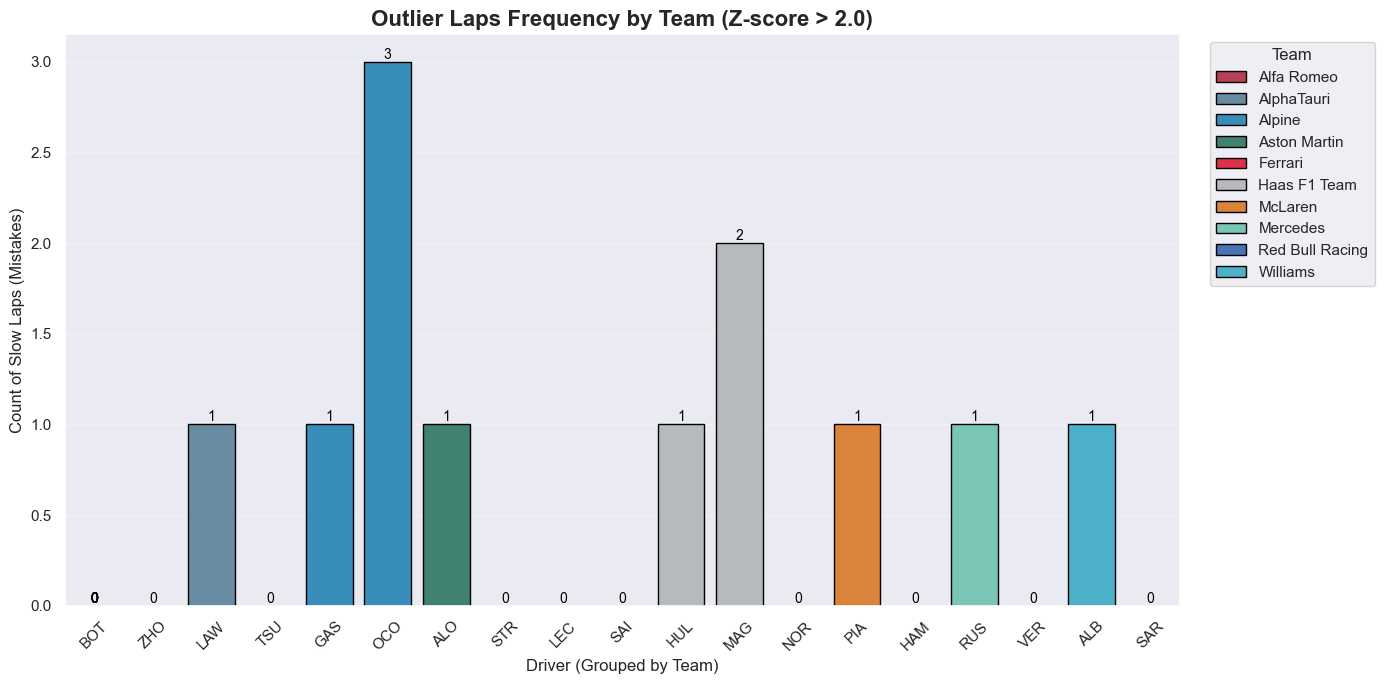

Top 5 Mistake Prone Drivers (in Clean Air):
   Driver          Team  Error_Count
14    OCO        Alpine          3.0
16    MAG  Haas F1 Team          2.0
5     LAW    AlphaTauri          1.0
12    RUS      Mercedes          1.0
3     ALB      Williams          1.0


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. 데이터 준비 (이전 단계와 동일)
driver_team_map = race.results.set_index('Abbreviation')['TeamName'].to_dict()
clean_laps = ds_b.copy()
clean_laps['Team'] = clean_laps['Driver'].map(driver_team_map)
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

# 2. Z-score 및 Outlier 계산 (Threshold 2.0)
def get_zscore(x):
    if len(x) < 5: return np.zeros(len(x))
    return stats.zscore(x, ddof=1)

clean_laps['Z_Score'] = clean_laps.groupby('Driver')['LapTimeSec'].transform(get_zscore)

mistake_threshold = 2.0
outliers = clean_laps[clean_laps['Z_Score'] > mistake_threshold].copy()

# 3. 집계
all_drivers = clean_laps['Driver'].unique()
outlier_counts = outliers.groupby(['Driver', 'Team']).size().reset_index(name='Error_Count')
full_driver_list = clean_laps[['Driver', 'Team']].drop_duplicates()
final_df = pd.merge(full_driver_list, outlier_counts, on=['Driver', 'Team'], how='left').fillna(0)
final_df = final_df.sort_values(by=['Team', 'Driver'])

# --- 🛠️ FIX: Team Color 직접 추출 ---
# race.results에서 TeamName과 TeamColor(Hex Code) 매핑을 직접 생성
team_color_map = race.results.set_index('TeamName')['TeamColor'].to_dict()

# Hex Code 포맷팅 (혹시 '#'이 빠져있을 경우 대비)
formatted_team_colors = {}
for team, color in team_color_map.items():
    # 값이 없거나 nan인 경우 회색 처리
    if pd.isna(color) or color == '':
        formatted_team_colors[team] = '#808080'
    elif not str(color).startswith('#'):
        formatted_team_colors[team] = '#' + str(color)
    else:
        formatted_team_colors[team] = str(color)

# 4. Visualization
plt.figure(figsize=(14, 7))

barplot = sns.barplot(
    data=final_df,
    x='Driver',
    y='Error_Count',
    hue='Team',
    palette=formatted_team_colors, # 수정된 컬러 맵 사용
    dodge=False,
    edgecolor='black'
)

plt.title(f'Outlier Laps Frequency by Team (Z-score > {mistake_threshold})', fontsize=16, fontweight='bold')
plt.ylabel('Count of Slow Laps (Mistakes)', fontsize=12)
plt.xlabel('Driver (Grouped by Team)', fontsize=12)
plt.legend(title='Team', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# 막대 위 숫자 표시
for p in barplot.patches:
    height = p.get_height()
    if height >= 0:
        barplot.annotate(f'{int(height)}', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Top 5 Mistake Prone Drivers (in Clean Air):")
print(final_df.sort_values('Error_Count', ascending=False).head())

## Driver Consistency: Best vs Average Sector Gap

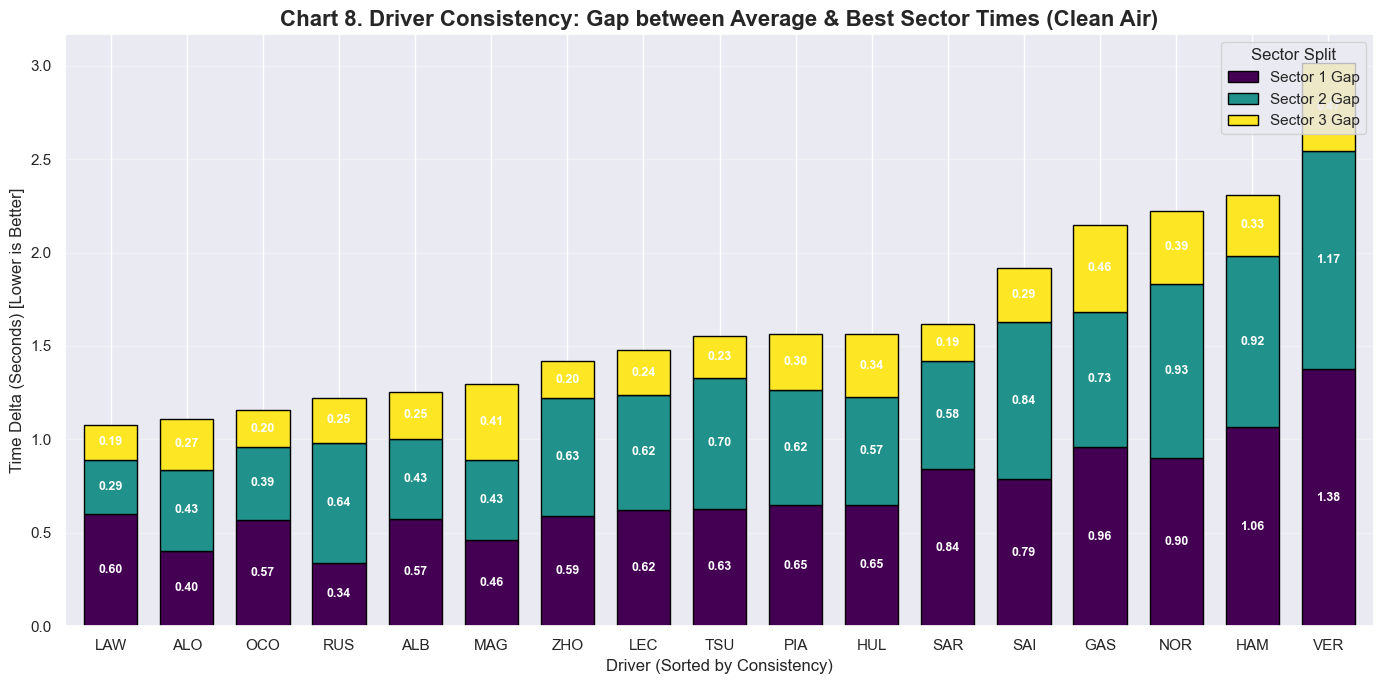

🏆 Top 3 Most Consistent Drivers (Lowest Total Gap):
        Total Gap
Driver           
LAW      1.077389
ALO      1.109964
OCO      1.155000

⚠️ Least Consistent Drivers (Highest Total Gap):
        Total Gap
Driver           
NOR      2.224024
HAM      2.309923
VER      3.016238


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비: Clean Air Dataset (ds_b)
# 충분한 샘플이 있는 드라이버만 분석 (예: 5랩 이상 Clean Air 주행한 드라이버)
clean_laps = ds_b.copy()
lap_counts = clean_laps['Driver'].value_counts()
valid_drivers = lap_counts[lap_counts >= 5].index.tolist()

sector_df = clean_laps[clean_laps['Driver'].isin(valid_drivers)].copy()

# 2. Sector Time 전처리 (Timedelta -> Seconds 변환)
cols = ['Sector1Time', 'Sector2Time', 'Sector3Time']
for col in cols:
    sector_df[f'{col}_Sec'] = sector_df[col].dt.total_seconds()

# 3. Aggregation (Driver별 Min, Mean 계산)
# 각 섹터별로 최솟값(Best)과 평균값(Average)을 구합니다.
agg_funcs = {
# Gap이 0에 가까울수록 "Best Lap을 매 랩마다 재현하고 있음"을 의미
    'Sector1Time_Sec': ['min', 'mean'],
    'Sector2Time_Sec': ['min', 'mean'],
    'Sector3Time_Sec': ['min', 'mean']
}
sector_stats = sector_df.groupby('Driver').agg(agg_funcs)

# 4. Gap Calculation (Mean - Min)
gap_df = pd.DataFrame(index=sector_stats.index)
gap_df['Sector 1 Gap'] = sector_stats['Sector1Time_Sec']['mean'] - sector_stats['Sector1Time_Sec']['min']
gap_df['Sector 2 Gap'] = sector_stats['Sector2Time_Sec']['mean'] - sector_stats['Sector2Time_Sec']['min']
gap_df['Sector 3 Gap'] = sector_stats['Sector3Time_Sec']['mean'] - sector_stats['Sector3Time_Sec']['min']

# 정렬: Total Gap이 작은 순서대로 (일관성 높은 순서)
gap_df['Total Gap'] = gap_df.sum(axis=1)
gap_df = gap_df.sort_values('Total Gap', ascending=True)

# 시각화를 위해 Total Gap 컬럼 제거 (스택 차트에는 방해됨)
plot_data = gap_df.drop(columns=['Total Gap'])

# 5. Visualization
ax = plot_data.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 7), 
    colormap='viridis', # 섹터별 구분감
    edgecolor='black',
    width=0.7
)

plt.title('Chart 8. Driver Consistency: Gap between Average & Best Sector Times (Clean Air)', fontsize=16, fontweight='bold')
plt.ylabel('Time Delta (Seconds) [Lower is Better]', fontsize=12)
plt.xlabel('Driver (Sorted by Consistency)', fontsize=12)
plt.legend(title='Sector Split', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)

# 값 표시 (각 세그먼트 중앙에)
for c in ax.containers:
    # 값이 너무 작으면 숫자 표시 생략 (가독성 위함)
    labels = [f'{v:.2f}' if v > 0.05 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

plt.tight_layout()
plt.show()

# --- 🔍 데이터 인사이트 출력 ---
print("🏆 Top 3 Most Consistent Drivers (Lowest Total Gap):")
print(gap_df[['Total Gap']].head(3))
print("\n⚠️ Least Consistent Drivers (Highest Total Gap):")
print(gap_df[['Total Gap']].tail(3))

## RPM-Speed Difference (SLIP_DELTA Distribution)

🚀 Processing Telemetry Data for SLIP_DELTA...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33020\1868544326.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gear_ratios = tel.groupby('nGear').apply(lambda x: (x['Speed'] / x['RPM']).median())
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33020\1868544326.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gear_ratios = tel.groupby('nGear').apply(lambda x: (x['Speed'] / x['RPM']).median()

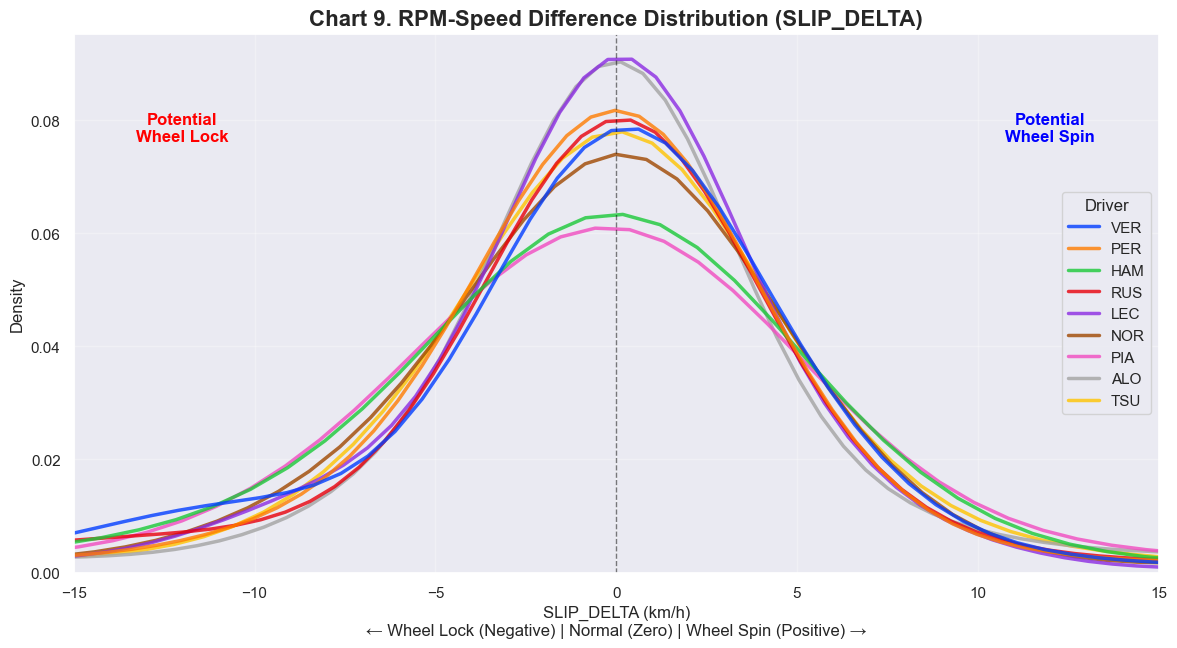

📊 Average Slip Instability (Mean Absolute Error of Slip Delta):
Driver
PIA    7.065602
HAM    6.693028
RUS    5.865414
NOR    5.722103
VER    5.675805
PER    5.446946
TSU    5.408529
ALO    5.060614
LEC    4.662403
Name: SLIP_DELTA, dtype: float64


In [18]:
import fastf1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 분석 대상 드라이버 선정 (Top Teams + 관심 드라이버)
target_drivers = ['VER', 'PER', 'HAM', 'RUS', 'LEC', 'SAINZ', 'NOR', 'PIA', 'ALO', 'TSU']
telemetry_list = []

print("🚀 Processing Telemetry Data for SLIP_DELTA...")

# 2. 드라이버별 Telemetry 데이터 추출 및 Feature Engineering
for driver in target_drivers:
    try:
        # 해당 드라이버의 가장 빠른 랩 추출 (Qualifying 데이터 ds_a 사용)
        driver_laps = ds_a[ds_a['Driver'] == driver]
        if driver_laps.empty:
            continue
            
        fastest_lap = driver_laps.pick_fastest()
        
        # Telemetry 로드 (Speed, RPM, nGear 등 포함)
        tel = fastest_lap.get_telemetry()
        
        # 데이터 정제: 기어 0(중립/후진) 및 저속 구간 제외
        tel = tel[(tel['nGear'] > 0) & (tel['Speed'] > 50)].copy()
        
        # --- Feature Engineering: Gear Ratio Estimation ---
        # F1 차량은 기어별로 엔진 RPM과 휠 속도가 고정된 비율(Gear Ratio)을 가짐
        # 각 기어(nGear)별로 (Speed / RPM)의 중앙값(Median)을 '정상 비율'로 추정
        gear_ratios = tel.groupby('nGear').apply(lambda x: (x['Speed'] / x['RPM']).median())
        
        # 추정 비율 매핑
        tel['Ratio'] = tel['nGear'].map(gear_ratios)
        
        # Estimated Speed (이론상 속도) = RPM * Ratio
        tel['Est_Speed'] = tel['RPM'] * tel['Ratio']
        
        # SLIP_DELTA = Estimated Speed - Actual Speed
        # 이론상 속도와 실제 속도의 차이 계산
        tel['SLIP_DELTA'] = tel['Est_Speed'] - tel['Speed']
        tel['Driver'] = driver
        
        # 분석에 필요한 컬럼만 저장
        telemetry_list.append(tel[['Driver', 'Date', 'RPM', 'Speed', 'nGear', 'SLIP_DELTA']])
        
    except Exception as e:
        print(f"⚠️ Error processing {driver}: {e}")

# 전체 데이터 병합
all_tel = pd.concat(telemetry_list, ignore_index=True)

# 3. Visualization (Density Plot)
plt.figure(figsize=(14, 7))

# KDE Plot 그리기
# common_norm=False: 각 드라이버별로 밀도 함수를 독립적으로 그림 (비교 용이)
sns.kdeplot(
    data=all_tel, 
    x='SLIP_DELTA', 
    hue='Driver', 
    fill=False,        # 선만 표시하여 겹침 방지
    common_norm=False, 
    palette='bright', 
    linewidth=2.5,
    alpha=0.8
)

# 4. 차트 꾸미기 및 해석 가이드
plt.title('Chart 9. RPM-Speed Difference Distribution (SLIP_DELTA)', fontsize=16, fontweight='bold')
plt.xlabel('SLIP_DELTA (km/h)\n← Wheel Lock (Negative) | Normal (Zero) | Wheel Spin (Positive) →', fontsize=12)
plt.ylabel('Density', fontsize=12)

# X축 범위 제한 (극단적인 값 제외하고 패턴 확인)
plt.xlim(-15, 15)
plt.grid(True, alpha=0.3)

# 기준선 (0)
plt.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)

# 해석 텍스트 추가
plt.text(-12, plt.ylim()[1]*0.8, 'Potential\nWheel Lock', color='red', ha='center', fontweight='bold')
plt.text(12, plt.ylim()[1]*0.8, 'Potential\nWheel Spin', color='blue', ha='center', fontweight='bold')

plt.show()

# --- 🔍 통계적 요약 (누가 가장 불안정한가?) ---
# SLIP_DELTA의 절대값 평균이 클수록 '미세한 슬립'이 많다는 뜻
print("📊 Average Slip Instability (Mean Absolute Error of Slip Delta):")
stability_score = all_tel.groupby('Driver')['SLIP_DELTA'].apply(lambda x: x.abs().mean()).sort_values(ascending=False)
print(stability_score)

🚀 Processing Telemetry for 19 Drivers...


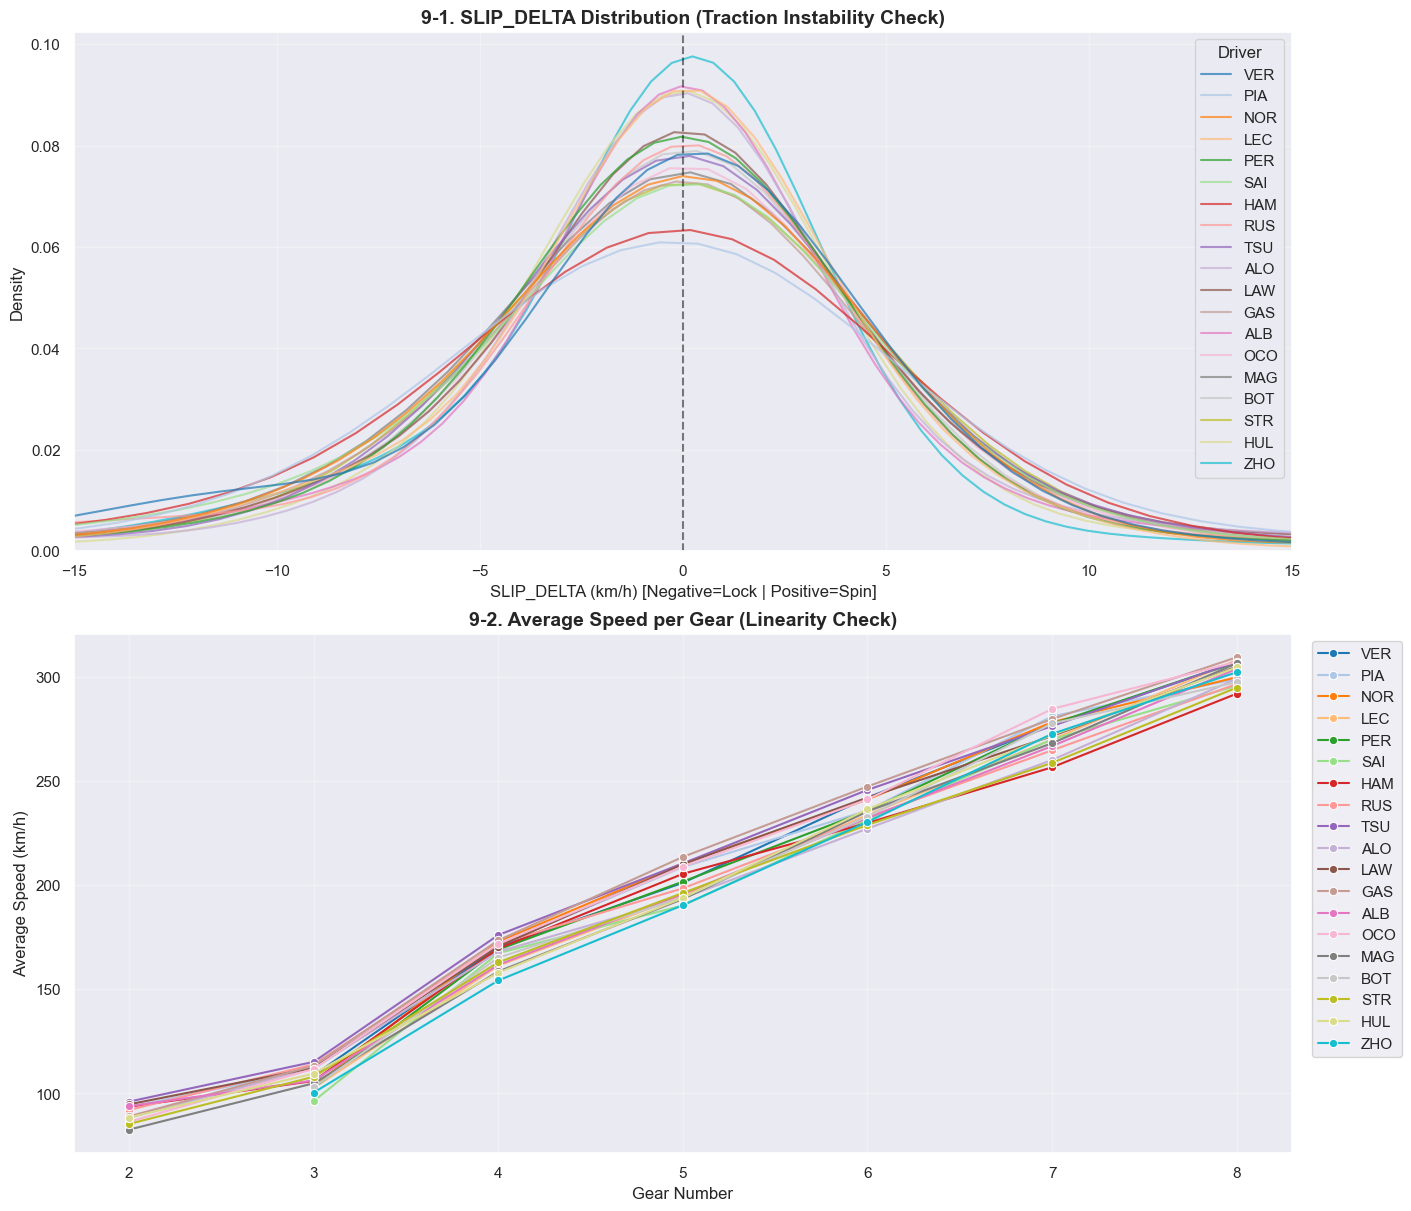

🔍 [Data Check] Drivers with highest instability (Mean Abs Slip Delta):
Driver
PIA    7.065602
HAM    6.693028
GAS    6.192373
STR    6.021561
SAI    6.015430
OCO    5.948284
RUS    5.865414
NOR    5.722103
VER    5.675805
BOT    5.548583
PER    5.446946
MAG    5.435372
TSU    5.408529
ALB    5.120720
LAW    5.087389
ALO    5.060614
HUL    4.920577
ZHO    4.675243
LEC    4.662403
Name: SLIP_DELTA, dtype: float64

📊 --- Statistical Hypothesis Testing ---
1. Kruskal-Wallis Test (Distribution Difference):
   - Statistic: 3.65
   - P-value: 9.9988e-01
   👉 Result: No significant difference found.

2. Levene's Test (Variance/Instability Difference):
   - Statistic: 2.12
   - P-value: 3.7668e-03
   👉 Result: Significant difference in driving instability (variance).


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33020\2083305498.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_slip_data, x='Driver', y='SLIP_DELTA', palette='tab20', showfliers=False) # Outlier 제외하고 몸통 비교


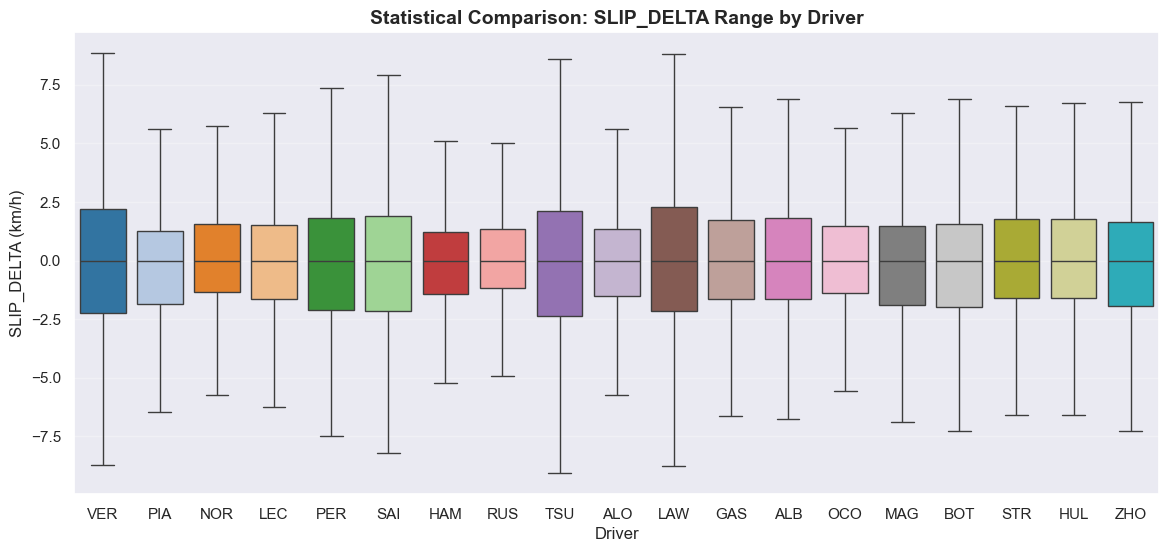

In [31]:
import fastf1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전체 드라이버 리스트 추출 (Dataset A 기준)
all_drivers = ds_a['Driver'].unique()

telemetry_list = []
gear_stats_list = []

print(f"🚀 Processing Telemetry for {len(all_drivers)} Drivers...")

# 2. 루프: 드라이버별 데이터 처리
for driver in all_drivers:
    try:
        # 드라이버별 Fastest Lap
        driver_laps = ds_a[ds_a['Driver'] == driver]
        if driver_laps.empty: continue
        
        fastest_lap = driver_laps.pick_fastest()
        tel = fastest_lap.get_telemetry()
        
        # 전처리: 기어 0 제외, 저속 주행(피트/서행) 제외
        tel = tel[(tel['nGear'] > 0) & (tel['Speed'] > 30)].copy()
        
        # --- Feature 1: SLIP_DELTA Calculation (Fix Warning) ---
        # Gear Ratio 추정 (Median 사용)
        # 수정됨: apply lambda 대신 벡터 연산 후 groupby().median() 사용
        # 1) 전체 데이터에 대해 Ratio 계산 (Vectorized operation)
        ratio_series = tel['Speed'] / tel['RPM']
        
        # 2) nGear 별로 중앙값 계산
        gear_ratios = ratio_series.groupby(tel['nGear']).median()
        
        tel['Ratio'] = tel['nGear'].map(gear_ratios)
        tel['Est_Speed'] = tel['RPM'] * tel['Ratio']
        tel['SLIP_DELTA'] = tel['Est_Speed'] - tel['Speed']
        tel['Driver'] = driver
        
        # KDE용 데이터 저장
        telemetry_list.append(tel[['Driver', 'SLIP_DELTA']])
        
        # --- Feature 2: Gear vs Speed Stats ---
        # 기어별 평균 속도 계산
        gear_summary = tel.groupby('nGear')['Speed'].mean().reset_index()
        gear_summary['Driver'] = driver
        gear_stats_list.append(gear_summary)
        
    except Exception as e:
        print(f"⚠️ Skip {driver}: {e}")

# 데이터 병합
if telemetry_list:
    all_slip_data = pd.concat(telemetry_list, ignore_index=True)
    all_gear_stats = pd.concat(gear_stats_list, ignore_index=True)

    # 3. Visualization (2 Subplots)
    fig, axes = plt.subplots(2, 1, figsize=(14, 12), constrained_layout=True)

    # --- Subplot 1: SLIP_DELTA Distribution (All Drivers) ---
    sns.kdeplot(
        data=all_slip_data, 
        x='SLIP_DELTA', 
        hue='Driver', 
        palette='tab20', 
        fill=False, 
        common_norm=False, 
        linewidth=1.5,
        alpha=0.7,
        ax=axes[0]
    )
    axes[0].set_title('9-1. SLIP_DELTA Distribution (Traction Instability Check)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('SLIP_DELTA (km/h) [Negative=Lock | Positive=Spin]')
    axes[0].set_xlim(-15, 15)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)

    # --- Subplot 2: Average Speed per Gear (All Drivers) ---
    sns.lineplot(
        data=all_gear_stats,
        x='nGear',
        y='Speed',
        hue='Driver',
        palette='tab20',
        marker='o',
        markersize=6,
        linewidth=1.5,
        ax=axes[1]
    )
    axes[1].set_title('9-2. Average Speed per Gear (Linearity Check)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Gear Number')
    axes[1].set_ylabel('Average Speed (km/h)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)

    plt.show()

    # --- 📊 Insight Check ---
    print("🔍 [Data Check] Drivers with highest instability (Mean Abs Slip Delta):")
    instability = all_slip_data.groupby('Driver')['SLIP_DELTA'].apply(lambda x: x.abs().mean()).sort_values(ascending=False)
    print(instability)

    from scipy import stats

    # 1. 데이터 준비: 드라이버별 SLIP_DELTA 데이터를 리스트로 분리
    drivers = all_slip_data['Driver'].unique()
    groups = [all_slip_data[all_slip_data['Driver'] == d]['SLIP_DELTA'].values for d in drivers]

    print("\n📊 --- Statistical Hypothesis Testing ---")

    # 2. Kruskal-Wallis Test (중앙값 차이 검정)
    # H0: 모든 드라이버의 SLIP_DELTA 중앙값은 같다.
    # H1: 적어도 한 드라이버의 중앙값은 다르다.
    stat, p_value = stats.kruskal(*groups)

    print(f"1. Kruskal-Wallis Test (Distribution Difference):")
    print(f"   - Statistic: {stat:.2f}")
    print(f"   - P-value: {p_value:.4e}")
    if p_value < 0.05:
        print("   👉 Result: Significant difference found between drivers' slip distributions.")
    else:
        print("   👉 Result: No significant difference found.")

    # 3. Levene's Test (분산/불안정성 차이 검정)
    # H0: 모든 드라이버의 SLIP_DELTA 분산은 같다.
    # H1: 적어도 한 드라이버의 분산(불안정도)은 다르다.
    stat_var, p_val_var = stats.levene(*groups, center='median') # median is robust for outliers

    print(f"\n2. Levene's Test (Variance/Instability Difference):")
    print(f"   - Statistic: {stat_var:.2f}")
    print(f"   - P-value: {p_val_var:.4e}")
    if p_val_var < 0.05:
        print("   👉 Result: Significant difference in driving instability (variance).")
    else:
        print("   👉 Result: Drivers have similar stability levels.")

    # 4. 시각적 검증 (Box Plot)
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=all_slip_data, x='Driver', y='SLIP_DELTA', palette='tab20', showfliers=False) # Outlier 제외하고 몸통 비교
    plt.title('Statistical Comparison: SLIP_DELTA Range by Driver', fontsize=14, fontweight='bold')
    plt.ylabel('SLIP_DELTA (km/h)')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

else:
    print("No data processed. Please check if ds_a (Dataset A) is loaded correctly.")

## Driver Clustering

🚀 Calculating Fuel-Corrected Metrics (Correction: +0.06s/lap)...


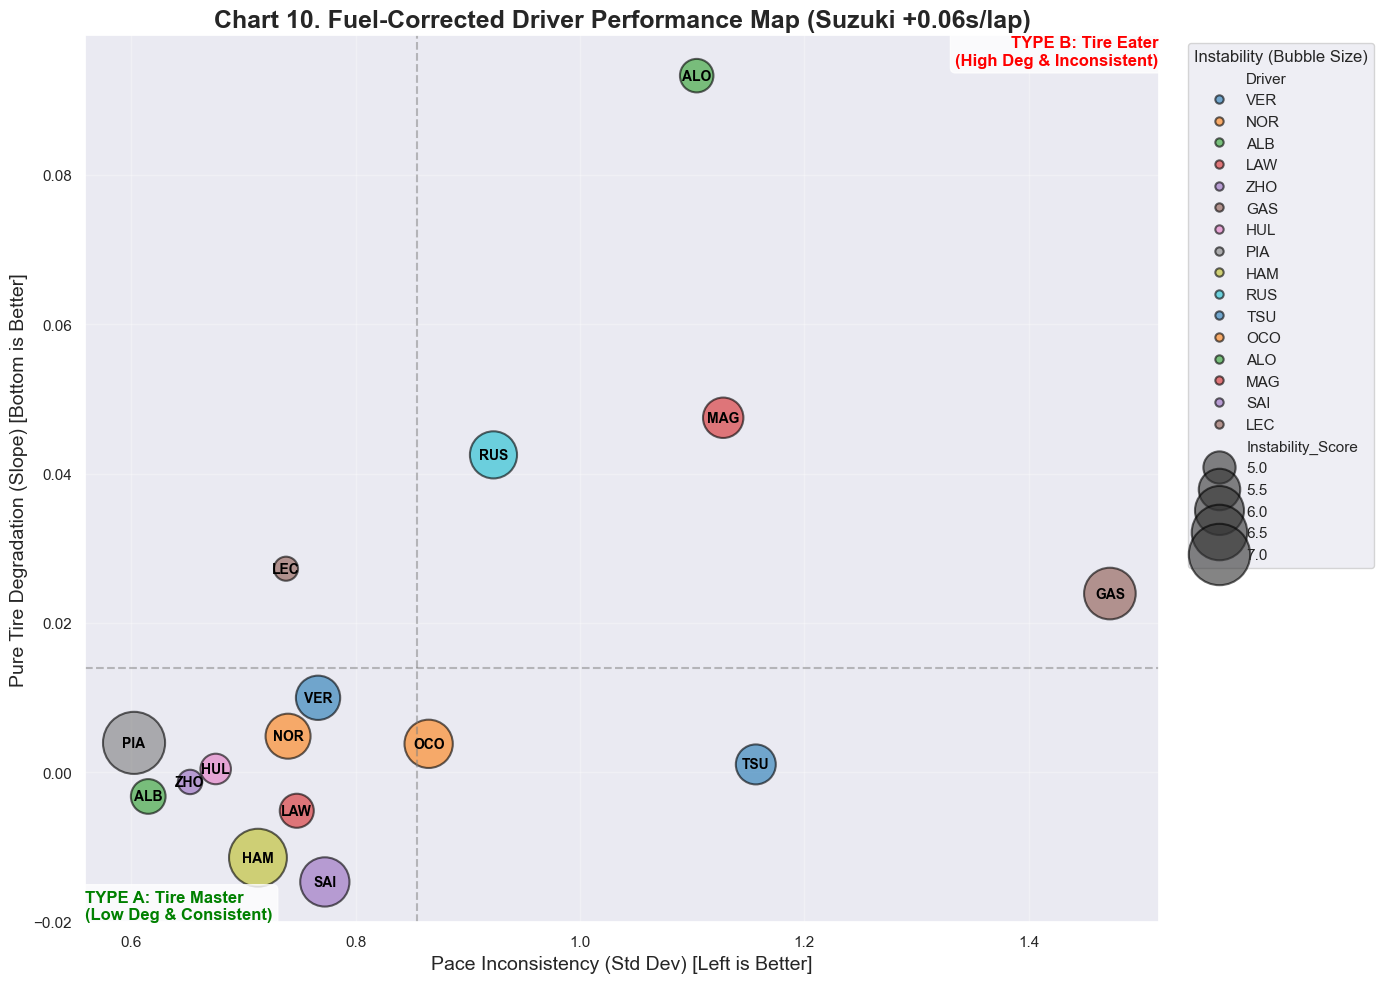

🔍 [Fuel Corrected Analysis]
   Driver  Tire_Deg_Slope  Consistency_Std
14    SAI       -0.014666         0.772538
8     HAM       -0.011423         0.712922
3     LAW       -0.005138         0.747533
2     ALB       -0.003222         0.615108
4     ZHO       -0.001282         0.652391
6     HUL        0.000456         0.675237
10    TSU        0.001065         1.156737
11    OCO        0.003822         0.865083
7     PIA        0.003951         0.602452
1     NOR        0.004844         0.739757
0     VER        0.009985         0.766483
5     GAS        0.023941         1.472392
15    LEC        0.027267         0.737926
9     RUS        0.042506         0.922872
13    MAG        0.047472         1.127667
12    ALO        0.093273         1.104033


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. 설정 및 데이터 준비
FUEL_PENALTY_PER_LAP = 0.06  # Suzuka Avg: 0.06s per lap gain due to fuel burn
min_laps = 5

print(f"🚀 Calculating Fuel-Corrected Metrics (Correction: +{FUEL_PENALTY_PER_LAP}s/lap)...")

# Clean Air Dataset 복사
clean_laps = ds_b.copy()
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

# --- 🟢 핵심: 연료 보정 랩타임 계산 ---
# 랩이 지날수록 차가 가벼워져서 빨라지는 성분(0.06 * Lap)을 더해서 상쇄시킴
clean_laps['Corrected_LapTime'] = clean_laps['LapTimeSec'] + (FUEL_PENALTY_PER_LAP * clean_laps['LapNumber'])

stats_list = []
target_drivers = clean_laps['Driver'].unique()

# 2. Race Metrics 계산 (Fuel Corrected)
for driver in target_drivers:
    driver_data = clean_laps[clean_laps['Driver'] == driver]
    
    if len(driver_data) < min_laps:
        continue
        
    # Metric 1: Consistency (Std Dev of CORRECTED Time)
    # 연료 효과를 제거한 후의 편차가 진짜 드라이버의 기복임
    consistency = driver_data['Corrected_LapTime'].std()
    
    # Metric 2: Tire Degradation (Slope of CORRECTED Time)
    # 보정된 랩타임의 기울기. (양수 = 순수 타이어 마모로 느려짐)
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        driver_data['LapNumber'], driver_data['Corrected_LapTime']
    )
    
    stats_list.append({
        'Driver': driver,
        'Consistency_Std': consistency,
        'Tire_Deg_Slope': slope
    })

perf_df = pd.DataFrame(stats_list)

# 3. Physical Metrics (SLIP_DELTA - Bubble Size) - Chart 9 로직 재사용
slip_metrics = []
for driver in perf_df['Driver'].unique():
    try:
        d_laps = ds_a[ds_a['Driver'] == driver]
        if d_laps.empty: continue
        fast_lap = d_laps.pick_fastest()
        tel = fast_lap.get_telemetry()
        tel = tel[(tel['nGear'] > 0) & (tel['Speed'] > 50)]
        
        # Vectorized Groupby Optimization
        ratio_series = tel['Speed'] / tel['RPM']
        gear_ratios = ratio_series.groupby(tel['nGear']).median()
        tel['Ratio'] = tel['nGear'].map(gear_ratios)
        tel['Est_Speed'] = tel['RPM'] * tel['Ratio']
        tel['SLIP_DELTA'] = tel['Est_Speed'] - tel['Speed']
        
        instability = tel['SLIP_DELTA'].abs().mean()
        slip_metrics.append({'Driver': driver, 'Instability_Score': instability})
    except:
        pass

# 최종 데이터 병합
slip_df = pd.merge(perf_df, pd.DataFrame(slip_metrics), on='Driver', how='inner')

# 4. Visualization
plt.figure(figsize=(14, 10))

scatter = sns.scatterplot(
    data=slip_df,
    x='Consistency_Std',
    y='Tire_Deg_Slope',
    size='Instability_Score',
    sizes=(300, 2000),
    hue='Driver',
    palette='tab10',
    alpha=0.6,
    edgecolor='black',
    linewidth=1.5
)

# 드라이버 이름
for i, row in slip_df.iterrows():
    plt.text(row['Consistency_Std'], row['Tire_Deg_Slope'], row['Driver'], 
             fontsize=10, weight='bold', ha='center', va='center', color='black')

# 4분면 기준선
mean_x = slip_df['Consistency_Std'].mean()
mean_y = slip_df['Tire_Deg_Slope'].mean()
plt.axvline(mean_x, color='gray', linestyle='--', alpha=0.5)
plt.axhline(mean_y, color='gray', linestyle='--', alpha=0.5)

# 타이틀 및 축 설정
plt.title(f'Chart 10. Fuel-Corrected Driver Performance Map (Suzuki +{FUEL_PENALTY_PER_LAP}s/lap)', fontsize=18, fontweight='bold')
plt.xlabel('Pace Inconsistency (Std Dev) [Left is Better]', fontsize=14)
plt.ylabel('Pure Tire Degradation (Slope) [Bottom is Better]', fontsize=14)

# 4분면 해석
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(x_min, y_min, 'TYPE A: Tire Master\n(Low Deg & Consistent)', 
         ha='left', va='bottom', fontsize=12, color='green', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.text(x_max, y_max, 'TYPE B: Tire Eater\n(High Deg & Inconsistent)', 
         ha='right', va='top', fontsize=12, color='red', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Instability (Bubble Size)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 📊 결과 출력 ---
print("🔍 [Fuel Corrected Analysis]")
print(slip_df[['Driver', 'Tire_Deg_Slope', 'Consistency_Std']].sort_values('Tire_Deg_Slope'))

🚀 Calculating De-trended Consistency Metrics...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33020\4246476356.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Driver', y='Consistency_Std', ax=axes[0], palette='viridis', edgecolor='black')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33020\4246476356.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df_iqr, x='Driver', y='Consistency_IQR', ax=axes[1], palette='magma', edgecolor='black')


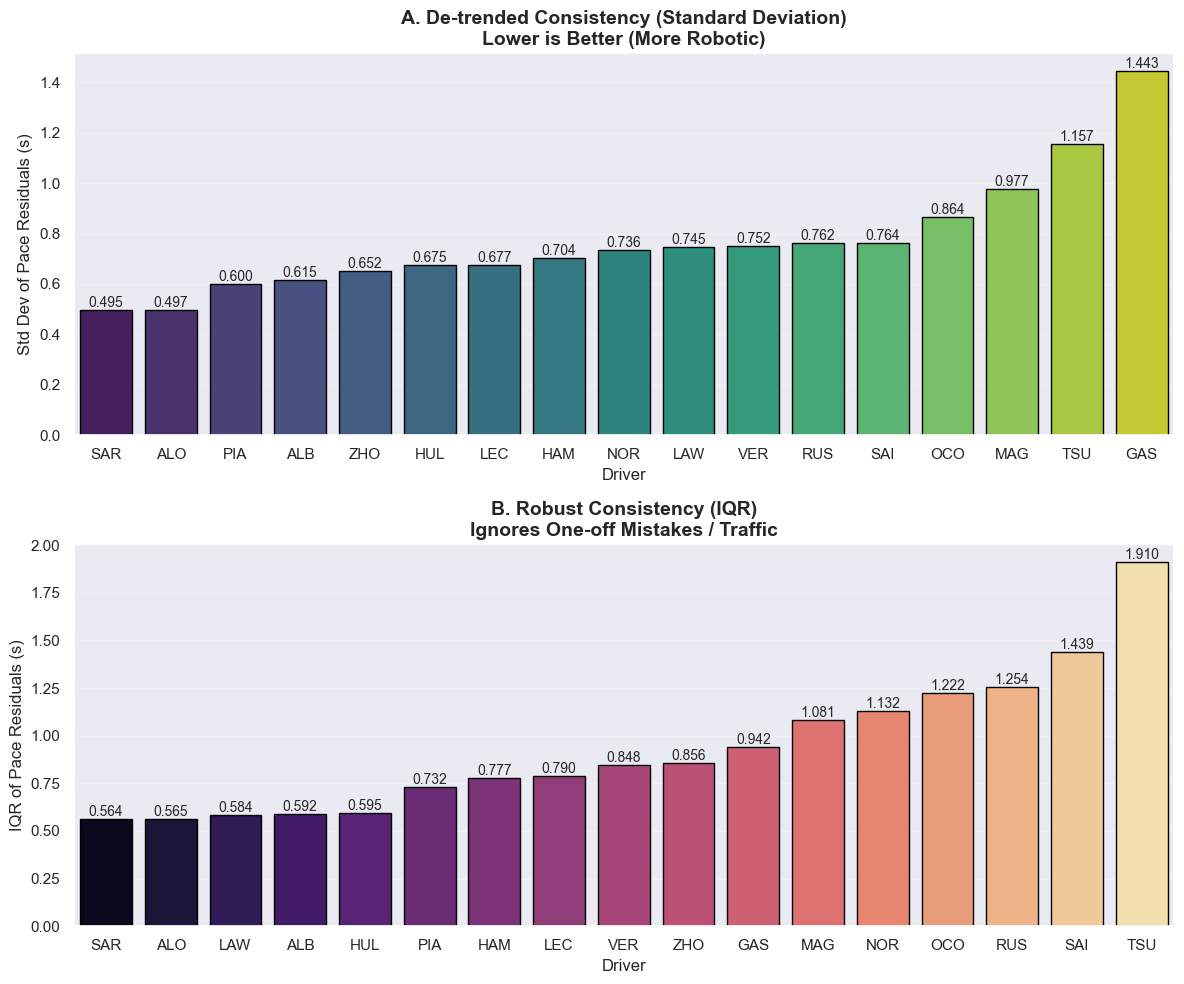

🏆 [True Consistency Ranking] Top 5 Drivers (Lowest Std Dev on Residuals):
Driver  Consistency_Std  Consistency_IQR
   SAR         0.495435         0.564475
   ALO         0.496675         0.565341
   PIA         0.600401         0.732148
   ALB         0.614815         0.591557
   ZHO         0.652188         0.855899

💡 해석 포인트:
1. 'Std Dev'가 낮다 = 마모 곡선을 따라 기계처럼 주행함 (Pace Management 달인)
2. 'IQR'이 'Std'보다 현저히 낮다 = 전반적으로 일관되나, 한두 번의 큰 실수(Outlier)가 있었다.


In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. 설정: Suzuka Fuel Penalty (약 0.06초/Lap)
FUEL_PENALTY = 0.06

# 데이터 준비 (Clean Air Dataset 복사)
# 최소 5랩 이상 달린 드라이버만 분석
consistency_df = ds_b.copy()
consistency_df['LapTimeSec'] = consistency_df['LapTime'].dt.total_seconds()
driver_counts = consistency_df['Driver'].value_counts()
target_drivers = driver_counts[driver_counts >= 5].index.tolist()

consistency_df = consistency_df[consistency_df['Driver'].isin(target_drivers)].copy()

print("🚀 Calculating De-trended Consistency Metrics...")

# 2. 핵심 로직: 연료 보정 및 추세(Tire Deg) 제거
# 목표: 드라이버가 의도한 '페이스 곡선'에서 벗어난 정도(Residuals)만 남기기

residuals_list = []

for driver in target_drivers:
    d_data = consistency_df[consistency_df['Driver'] == driver].copy()
    
    # A. 연료 보정 (Fuel Corrected Time)
    # 랩이 지날수록 차가 가벼워져 빨라지는 효과(+0.06s * Lap)를 더해서 상쇄
    d_data['Fuel_Corrected_Time'] = d_data['LapTimeSec'] + (d_data['LapNumber'] * FUEL_PENALTY)
    
    # B. 타이어 마모 추세 제거 (De-trending)
    # 연료 보정을 해도 타이어 마모로 인해 기록은 우상향(느려짐)합니다.
    # 이 '기울기'는 실력이 아니라 물리 현상이므로, 회귀선을 그려서 제거합니다.
    slope, intercept, _, _, _ = stats.linregress(d_data['LapNumber'], d_data['Fuel_Corrected_Time'])
    
    # 예상 랩타임 (Trend)
    trend_line = intercept + (slope * d_data['LapNumber'])
    
    # 잔차 (Residuals) = 실제 기록 - 예상 기록
    # 이 값이 0에 가까울수록 "타이어가 닳는 와중에도 완벽하게 계산된 주행"을 한 것입니다.
    d_data['Pace_Residual'] = d_data['Fuel_Corrected_Time'] - trend_line
    
    residuals_list.append(d_data[['Driver', 'LapNumber', 'Pace_Residual']])

# 전체 잔차 데이터 병합
residuals_df = pd.concat(residuals_list)

# 3. 새로운 Metric 계산 (Std Dev & IQR)
metrics_list = []

for driver in target_drivers:
    r_data = residuals_df[residuals_df['Driver'] == driver]['Pace_Residual']
    
    # Metric 1: Standard Deviation (표준편차)
    std_dev = r_data.std()
    
    # Metric 2: IQR (Interquartile Range) - 이상치(Outlier)에 강건함
    q75, q25 = np.percentile(r_data, [75 ,25])
    iqr = q75 - q25
    
    metrics_list.append({
        'Driver': driver,
        'Consistency_Std': std_dev,
        'Consistency_IQR': iqr
    })

metrics_df = pd.DataFrame(metrics_list).sort_values('Consistency_Std') # 낮은 순 정렬

# 4. 시각화 (Dual Plot)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Chart A: Standard Deviation (민감함)
sns.barplot(data=metrics_df, x='Driver', y='Consistency_Std', ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('A. De-trended Consistency (Standard Deviation)\nLower is Better (More Robotic)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Std Dev of Pace Residuals (s)')
axes[0].grid(axis='y', alpha=0.3)

# 값 표시
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10)

# Chart B: IQR (이상치 제외)
metrics_df_iqr = metrics_df.sort_values('Consistency_IQR')
sns.barplot(data=metrics_df_iqr, x='Driver', y='Consistency_IQR', ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('B. Robust Consistency (IQR)\nIgnores One-off Mistakes / Traffic', fontsize=14, fontweight='bold')
axes[1].set_ylabel('IQR of Pace Residuals (s)')
axes[1].grid(axis='y', alpha=0.3)

# 값 표시
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# --- 🔍 결과 해석 가이드 출력 ---
print("🏆 [True Consistency Ranking] Top 5 Drivers (Lowest Std Dev on Residuals):")
print(metrics_df[['Driver', 'Consistency_Std', 'Consistency_IQR']].head(5).to_string(index=False))

print("\n💡 해석 포인트:")
print("1. 'Std Dev'가 낮다 = 마모 곡선을 따라 기계처럼 주행함 (Pace Management 달인)")
print("2. 'IQR'이 'Std'보다 현저히 낮다 = 전반적으로 일관되나, 한두 번의 큰 실수(Outlier)가 있었다.")